In [11]:
#1
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()
image = Image.open(next(iter(uploaded)))

print("Image Size:", image.size)
print("Colour Mode:", image.mode)

Saving catss.jpg to catss (2).jpg
Image Size: (1920, 1200)
Colour Mode: RGB


In [12]:
#2
image = image.convert("RGB")
img_array = np.array(image)

print(img_array.shape)

(1200, 1920, 3)


In [13]:
#3
gray = image.convert("L")
img_array = np.array(gray)
normalized = img_array / 255.0
print(normalized)

[[0.03921569 0.03921569 0.03921569 ... 0.14901961 0.14901961 0.14901961]
 [0.03921569 0.03921569 0.03921569 ... 0.14509804 0.14509804 0.14509804]
 [0.03921569 0.03921569 0.03921569 ... 0.1372549  0.1372549  0.1372549 ]
 ...
 [0.07058824 0.07058824 0.07058824 ... 0.48627451 0.46666667 0.45882353]
 [0.07058824 0.07058824 0.07058824 ... 0.47843137 0.45882353 0.4627451 ]
 [0.07058824 0.07058824 0.07058824 ... 0.4745098  0.45882353 0.4627451 ]]


In [14]:
#4
gray = gray.resize((128,128))
img_array = np.array(gray)
cnn_input = img_array.reshape(1,128,128,1)

In [15]:
#5
Grayscale Image:
Total Pixels = Width x Height
= 512 x 512
= 262,144 pixels

RGB Image:
Total Pixel Values = Width x Height x 3
= 512 x 512 x 3
= 786,432 values

SyntaxError: invalid syntax (3883170272.py, line 2)

In [16]:
#6
matrix = np.random.randint(0,256,(5,5))
print(matrix)

[[ 37 113  50 244  94]
 [ 78 180 161 195  21]
 [ 50  25 194 149 173]
 [135 215 219 232 249]
 [200 196 147 112  24]]


In [17]:
#7
print(img_array[50,50])
img_array[50,50] = 255
print(img_array[50,50])

161
255


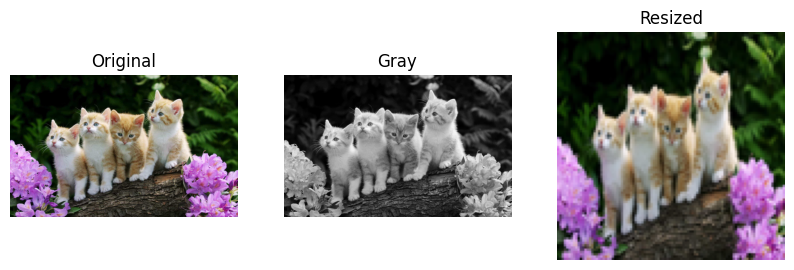

In [18]:
#8
gray = image.convert("L")
resized = image.resize((100,100))
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray,cmap="gray")
plt.title("Gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(resized)
plt.title("Resized")
plt.axis("off")

plt.show()

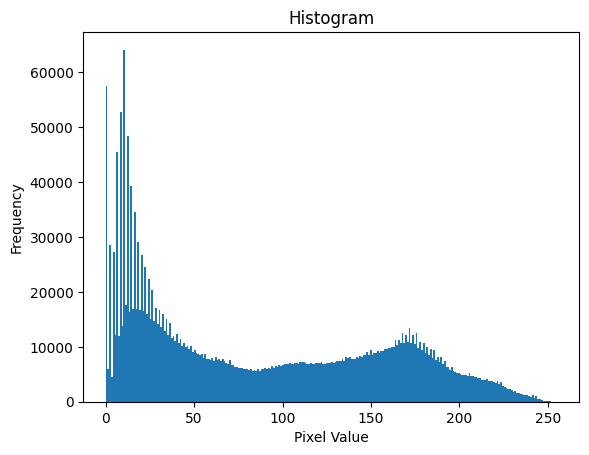

In [19]:
#9
plt.hist(np.array(gray).ravel(), bins=256)
plt.title("Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [20]:
#10
resized = image.resize((224,224))
gray = resized.convert("L")
gray.save("gray_image.jpg")
print("Image saved successfully.")

Image saved successfully.


In [21]:
import cv2

(1200, 1920, 3)


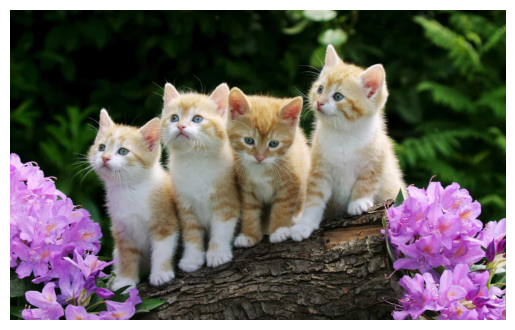

In [22]:
#11
img = cv2.imread(next(iter(uploaded)))
print(img.shape)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb)
plt.axis("off")
plt.show()

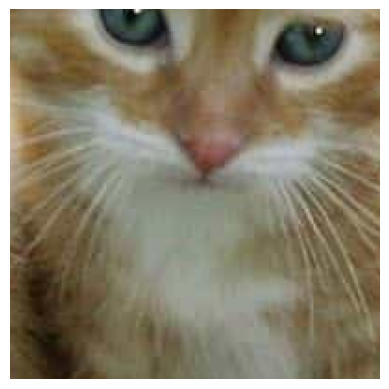

In [23]:
#12
h, w = img.shape[:2]
center_x = w // 2
center_y = h // 2
crop = img[center_y-100:center_y+100, center_x-100:center_x+100]
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

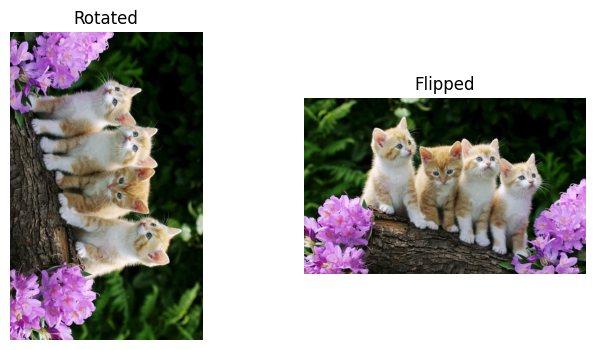

In [24]:
#13
rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
flipped = cv2.flip(img, 1)
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title("Rotated")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB))
plt.title("Flipped")
plt.axis("off")

plt.show()

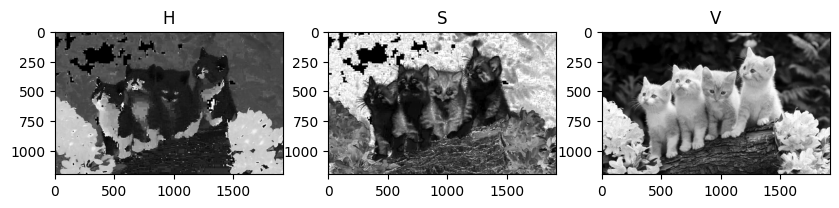

In [25]:
#14
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(h, cmap="gray")
plt.title("H")

plt.subplot(1,3,2)
plt.imshow(s, cmap="gray")
plt.title("S")

plt.subplot(1,3,3)
plt.imshow(v, cmap="gray")
plt.title("V")

plt.show()

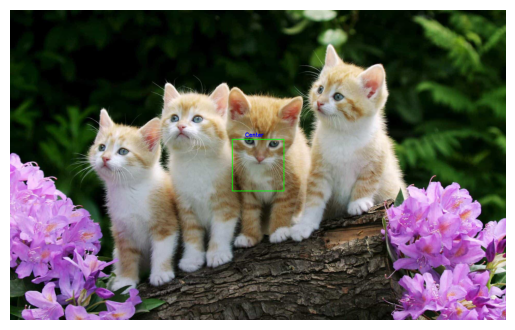

In [26]:
#15
copy = img.copy()
h, w = copy.shape[:2]
cv2.rectangle(copy, (w//2-100, h//2-100), (w//2+100, h//2+100), (0,255,0), 2)
cv2.putText(copy, "Center", (w//2-50, h//2-110),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)

plt.imshow(cv2.cvtColor(copy, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

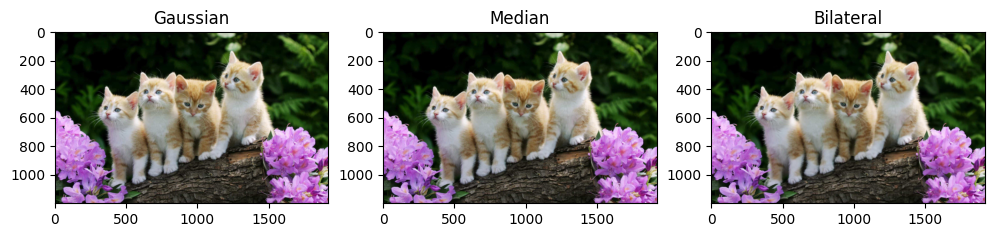

In [27]:
#16
gaussian = cv2.GaussianBlur(img, (5,5), 0)
median = cv2.medianBlur(img, 5)
bilateral = cv2.bilateralFilter(img, 9, 75, 75)
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB))
plt.title("Gaussian")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(median, cv2.COLOR_BGR2RGB))
plt.title("Median")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB))
plt.title("Bilateral")

plt.show()

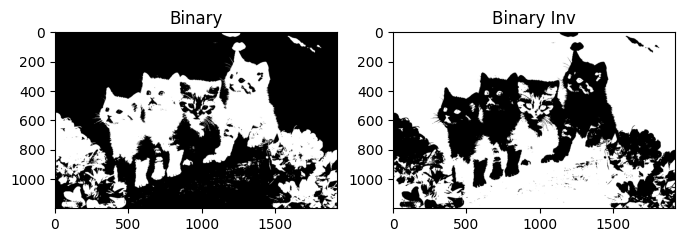

In [29]:
#17
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

_, inverse = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(binary, cmap="gray")
plt.title("Binary")

plt.subplot(1,2,2)
plt.imshow(inverse, cmap="gray")
plt.title("Binary Inv")
plt.show()

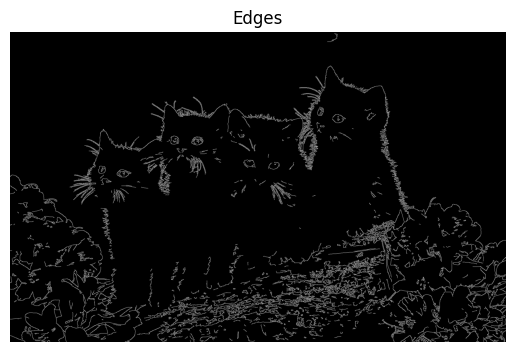

In [30]:
#18
edges = cv2.Canny(gray, 100, 200)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")
plt.show()

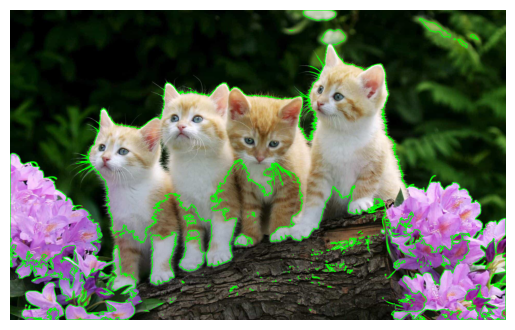

In [31]:
#19
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
copy = img.copy()
cv2.drawContours(copy, contours, -1, (0,255,0), 2)
plt.imshow(cv2.cvtColor(copy, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

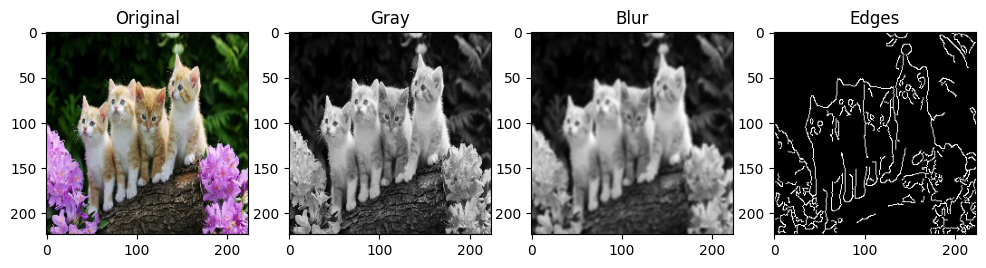

In [32]:
#20
img = cv2.imread(next(iter(uploaded)))
img = cv2.resize(img, (224,224))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
edges = cv2.Canny(blur, 100, 200)
plt.figure(figsize=(12,3))

plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,4,2)
plt.imshow(gray, cmap="gray")
plt.title("Gray")

plt.subplot(1,4,3)
plt.imshow(blur, cmap="gray")
plt.title("Blur")

plt.subplot(1,4,4)
plt.imshow(edges, cmap="gray")
plt.title("Edges")

plt.show()

In [33]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

In [34]:
#21
model = Sequential()
model.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dense(10, activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,682 (91.20 MB)

 Trainable params: 23,908,682 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
#22
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
#23
Given:
Input = 10 x 10
Filter = 3 x 3
Stride = 1
Padding = 0 (Valid)

After Conv2D
Output = (10 - 3)/1 + 1
       = 8

Output Shape = 8 x 8
After MaxPooling (2 x 2)
Output = 8 / 2
= 4
Output Shape = 4 x 4

In [36]:
#24
model = Sequential()
model.add(Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Flatten())

model.add(Dense(128,activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
#dataset
import numpy as np

X_train = np.random.rand(100,224,224,3)
y_train = np.eye(10)[np.random.randint(0,10,100)]

X_test = np.random.rand(20,224,224,3)
y_test = np.eye(10)[np.random.randint(0,10,20)]

In [42]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [43]:
#25
early_stop = EarlyStopping(monitor="val_loss", patience=3)
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.0500 - loss: 200.0414 - val_accuracy: 0.1500 - val_loss: 42.0873
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.1500 - loss: 270.0389 - val_accuracy: 0.1000 - val_loss: 16.2832
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.1900 - loss: 114.5713 - val_accuracy: 0.1000 - val_loss: 18.4219
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 27s 8s/step - accuracy: 0.1600 - loss: 48.8033 - val_accuracy: 0.1500 - val_loss: 5.6042
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.2300 - loss: 9.0365 - val_accuracy: 0.0500 - val_loss: 2.9777
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.2700 - loss: 3.4815 - val_accuracy: 0.1000 - val_loss: 2.7291
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.2700 - loss: 2.9210 - val_accuracy: 0.1000 - val_loss: 2.3015
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.1800 - loss: 3.0798 - val_accuracy: 0.1000 - val_loss: 2.301

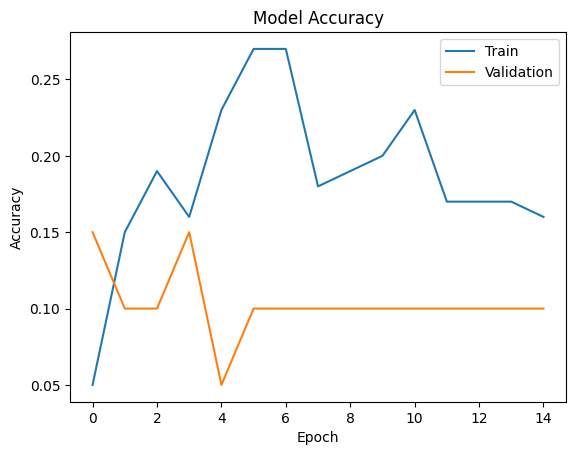

In [44]:
#26
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

In [45]:
#27
model.save("cnn_model.h5")
new_model = load_model("cnn_model.h5")

In [46]:
#28
img = image.resize((224,224))
img = np.array(img)
img = img / 255.0
img = img.reshape(1,224,224,3)
prediction = model.predict(img)
predicted_class = np.argmax(prediction)
print(predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
5


In [47]:
#29
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred)
print(cm)
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step
[[0 0 0 0 5 0 0 0 0]
 [0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 0]
 [0 0 0 0 2 0 0 0 0]
 [0 0 0 0 2 0 0 0 0]
 [0 0 0 0 3 0 0 0 0]
 [0 0 0 0 3 0 0 0 0]
 [0 0 0 0 2 0 0 0 0]]
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         5
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           5       0.10      1.00      0.18         2
           6       0.00      0.00      0.00         2
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         2

    accuracy                           0.10        20
   macro avg       0.01      0.11      0.02        20
weighted avg       0.01      0.10      0.02        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [48]:
#30
model = Sequential()

model.add(Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation="relu"))
model.add(Dense(10,activation="softmax"))

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=3)

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))
img = image.resize((224,224))
img = np.array(img) / 255.0
img = img.reshape(1,224,224,3)
prediction = model.predict(img)
print("Predicted Class:", np.argmax(prediction))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1277 - loss: 22.7203

4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.1200 - loss: 28.5421 - val_accuracy: 0.1000 - val_loss: 7.7438
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1132 - loss: 5.6774

4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.1300 - loss: 4.6809 - val_accuracy: 0.0500 - val_loss: 2.2475
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.1600 - loss: 2.2869 - val_accuracy: 0.0000e+00 - val_loss: 2.3138
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.1400 - loss: 2.2647 - val_accuracy: 0.2500 - val_loss: 2.2701
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.2600 - loss: 2.1939 - val_accuracy: 0.0000e+00 - val_loss: 2.2974
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step - accuracy: 0.0000e+00 - loss: 2.2974
Accuracy: 0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
[[0 0 0 0 0 0 0 0 0 0]
 [5 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0]
 [2 0 0 0 0 0 0 0 0 0]
 [2 0 0 0 0 0 0 0 0 0]
 [3 0 0 0 0 0 0 0 0 0]
 [3 0 0 0 0 0 0 0 0 0]
 [2 0 0 0 0 0 0 0 0 0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Predicted Class: 1
